In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os

print(os.listdir("/kaggle/input"))

[]


In [ ]:
import os

path = "C:\Users\sarah\Desktop\New folder\Suspicious-Network-Behavior-Detection\Data"

files = [os.path.join(path, f) for f in os.listdir(path)]

print("Total files:", len(files))


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/network-intrusion-dataset'

In [ ]:
import pandas as pd

df_list = []

for file in files:
    print("Reading:", file)
    df = pd.read_csv(file)
    df_list.append(df)

full_df = pd.concat(df_list, ignore_index=True)

print("Final Shape:", full_df.shape)

Reading: /kaggle/input/network-intrusion-dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Reading: /kaggle/input/network-intrusion-dataset/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Reading: /kaggle/input/network-intrusion-dataset/Tuesday-WorkingHours.pcap_ISCX.csv
Reading: /kaggle/input/network-intrusion-dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Reading: /kaggle/input/network-intrusion-dataset/Monday-WorkingHours.pcap_ISCX.csv
Reading: /kaggle/input/network-intrusion-dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv
Reading: /kaggle/input/network-intrusion-dataset/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Reading: /kaggle/input/network-intrusion-dataset/Wednesday-workingHours.pcap_ISCX.csv
Final Shape: (2830743, 79)


In [ ]:
full_df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830738,53,32215,4,2,112,152,28,28,28.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830739,53,324,2,2,84,362,42,42,42.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830740,58030,82,2,1,31,6,31,0,15.500000,21.920310,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830741,53,1048635,6,2,192,256,32,32,32.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
# Drop columns where all values are 0
full_df = full_df.loc[:, (full_df != 0).any(axis=0)]

print("New shape after dropping zero-only columns:", full_df.shape)

New shape after dropping zero-only columns: (2830743, 71)


In [ ]:
import numpy as np

print("Before cleaning:", full_df.shape)

# Remove duplicates
full_df = full_df.drop_duplicates()

# Replace infinity values with NaN
full_df = full_df.replace([np.inf, -np.inf], np.nan)

# Drop missing values
full_df = full_df.dropna()

print("After cleaning:", full_df.shape)

Before cleaning: (2830743, 71)
After cleaning: (2520798, 71)


In [ ]:
print(full_df.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Fwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length',
       ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance',
       'FIN Flag Count', ' SYN Flag Count', 

In [ ]:
full_df.columns = full_df.columns.str.strip()

In [ ]:
print(full_df['Label'].value_counts())

Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
full_df['Label'] = le.fit_transform(full_df['Label'])

print(full_df['Label'].value_counts())



Label
0     2095057
4      172846
2      128014
10      90694
3       10286
7        5931
6        5385
5        5228
11       3219
1        1948
12       1470
14        652
9          36
13         21
8          11
Name: count, dtype: int64


In [ ]:
X = full_df.drop('Label', axis=1)
y = full_df['Label']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2520798, 70)
Target shape: (2520798,)


In [ ]:
print(full_df['Label'].value_counts())

Label
0     2095057
4      172846
2      128014
10      90694
3       10286
7        5931
6        5385
5        5228
11       3219
1        1948
12       1470
14        652
9          36
13         21
8          11
Name: count, dtype: int64


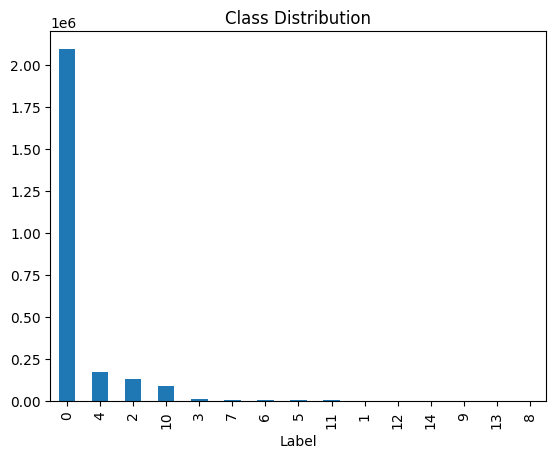

In [ ]:
import matplotlib.pyplot as plt

full_df['Label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
import pickle

# -----------------------------
# Step 1: Split the dataset
# -----------------------------
# X_scaled → Feature matrix (already scaled)
# y → Target labels
# test_size=0.2 → 20% data for testing
# stratify=y → Preserves class distribution (important for imbalance)
# random_state=42 → Ensures reproducibility

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train-test split completed successfully!")

# -----------------------------
# Step 2: Save the split data
# -----------------------------
# We save everything in a dictionary
# so that we can reload it later without re-splitting

split_data = {
    "X_train_real": X_train_real,
    "X_test_real": X_test_real,
    "y_train_real": y_train_real,
    "y_test_real": y_test_real
}

# Save using pickle
with open("train_test_split.pkl", "wb") as f:
    pickle.dump(split_data, f)

print("Train-test split saved successfully!")

Train-test split completed successfully!
Train-test split saved successfully!


In [ ]:
import pickle

# Load the saved split data
with open("train_test_split.pkl", "rb") as f:
    data = pickle.load(f)

# Extract variables back
X_train_real = data["X_train_real"]
X_test_real = data["X_test_real"]
y_train_real = data["y_train_real"]
y_test_real = data["y_test_real"]

print("Train-test split loaded successfully!")

Train-test split loaded successfully!


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 2: Scale
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit only on train
X_test_scaled = scaler.transform(X_test)        # only transform test

In [ ]:
import pickle

# Create a dictionary of everything you want to save
data_to_save = {
    "scaler": scaler,
    "X_train_scaled": X_train_scaled,
    "X_test_scaled": X_test_scaled,
    "y_train": y_train,
    "y_test": y_test
}

with open("preprocessed_data.pkl", "wb") as f:
    pickle.dump(data_to_save, f)

print("Preprocessed data saved successfully!")

Preprocessed data saved successfully!


In [ ]:
#Load
import pickle

with open("preprocessed_data.pkl", "rb") as f:
    loaded_data = pickle.load(f)

scaler = loaded_data["scaler"]
X_train_scaled = loaded_data["X_train_scaled"]
X_test_scaled = loaded_data["X_test_scaled"]
y_train = loaded_data["y_train"]
y_test = loaded_data["y_test"]

print("Preprocessed data loaded successfully!")

Preprocessed data loaded successfully!


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score

rf_real = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    random_state=42
)

rf_real.fit(X_train_real, y_train_real)

y_pred_real = rf_real.predict(X_test_real)

print("Accuracy:", accuracy_score(y_test_real, y_pred_real))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_real, y_pred_real))
print(classification_report(y_test_real, y_pred_real))

Accuracy: 0.9982862583306886
Balanced Accuracy: 0.842893676964833
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419012
           1       0.85      0.78      0.82       390
           2       1.00      1.00      1.00     25603
           3       1.00      0.99      0.99      2057
           4       1.00      1.00      1.00     34569
           5       0.99      1.00      0.99      1046
           6       0.99      0.99      0.99      1077
           7       1.00      1.00      1.00      1186
           8       1.00      0.50      0.67         2
           9       1.00      1.00      1.00         7
          10       0.99      0.99      0.99     18139
          11       1.00      1.00      1.00       644
          12       0.75      0.83      0.79       294
          13       1.00      0.25      0.40         4
          14       0.46      0.33      0.39       130

    accuracy                           1.00    504160
   macro avg  

In [ ]:
import pickle

with open("rf_real_model.pkl", "wb") as f:
    pickle.dump(rf_real, f)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [ ]:
#Load
import pickle

with open("rf_real_model.pkl", "rb") as f:
    rf_real = pickle.load(f)

print("Model loaded successfully!")

# Now directly predict
y_pred_real = rf_real.predict(X_test_real)

Model loaded successfully!


In [ ]:
import pandas as pd

X_train_df = pd.DataFrame(X_train_real, columns=X.columns)

train_df = X_train_df.copy()
train_df['Label'] = y_train_real.values

print("Training DataFrame shape:", train_df.shape)

Training DataFrame shape: (2016638, 71)


In [ ]:
from sklearn.model_selection import train_test_split

train_df_500k, _ = train_test_split(
    train_df,
    train_size=500000,
    stratify=train_df['Label'],
    random_state=42
)

print("Stratified 500k Shape:", train_df_500k.shape)
print("\nClass Distribution (Normalized):")
print(train_df_500k['Label'].value_counts(normalize=True))

Stratified 500k Shape: (500000, 71)

Class Distribution (Normalized):
Label
0     0.831108
4     0.068568
2     0.050784
10    0.035978
3     0.004080
7     0.002354
6     0.002136
5     0.002074
11    0.001278
1     0.000772
12    0.000584
14    0.000258
9     0.000014
13    0.000008
8     0.000004
Name: proportion, dtype: float64


In [ ]:
train_df_500k.to_csv("train_df_500k_stratified.csv", index=False)

print("Saved successfully as train_df_500k_stratified.csv")

Saved successfully as train_df_500k_stratified.csv


In [ ]:
!pip install --upgrade sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 kB 5.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 52.0 MB/s eta 0:00:0000:01


In [ ]:
import torch
from sdv.single_table import CTGANSynthesizer

print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))
print("Device count  →", torch.cuda.device_count())
print("Current device →", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA Available: True
GPU Name: Tesla T4
Device count  → 2
Current device → Tesla T4


In [ ]:
print(train_df.isnull().sum().sum())

0


In [ ]:
categorical_columns = ['Label']

In [ ]:
print(train_df.shape)

(2016638, 71)


In [ ]:
from sdv.metadata import Metadata
metadata = Metadata.detect_from_dataframe(
    data=train_df_500k)
# 2. Create the synthesizer

metadata.save_to_json('my_ctgan_metadata.json')  # Do this once after setup
ctgan = CTGANSynthesizer(
    metadata=metadata,           # ← this is required!
    epochs=20,
    batch_size=2000,
    enable_gpu=True,             
    verbose=True
)

In [ ]:
#print("CTGAN device:", ctgan._device)

In [ ]:
ctgan.fit(train_df_500k)

KeyboardInterrupt: 

In [ ]:
ctgan.save("ctgan_500k_20epochs.pkl")
print("Model saved successfully.")

In [ ]:
synthetic_data = ctgan.sample(500000)

print("Synthetic data shape:", synthetic_data.shape)
synthetic_data.head()

In [ ]:
synthetic_data.to_csv("synthetic_ctgan_500k.csv", index=False)
print("Synthetic data saved successfully.")

In [ ]:
#load saved model
ctgan = CTGAN.load("ctgan_500k_20epochs.pkl")
print("Model loaded successfully.")

In [ ]:
#load synthetic data
synthetic_data = pd.read_csv("synthetic_ctgan_500k.csv")
print(synthetic_data.shape)

In [ ]:
# ----- Distribution Similarity: Mean & Standard Deviation Comparison -----

real_stats = train_df_500k.describe()
synthetic_stats = synthetic_data.describe()

comparison = pd.DataFrame({
    "Real Mean": real_stats.loc["mean"],
    "Synthetic Mean": synthetic_stats.loc["mean"],
    "Real Std": real_stats.loc["std"],
    "Synthetic Std": synthetic_stats.loc["std"]
})

comparison.head()

In [ ]:
# ----- Distribution Similarity: Correlation Matrix Comparison -----

real_corr = train_df_500k.corr()
synthetic_corr = synthetic_data.corr()

corr_diff = (real_corr - synthetic_corr).abs().mean().mean()

print("Average Correlation Difference:", corr_diff)

In [ ]:
# ----- TSTR Evaluation: Train on Synthetic, Test on Real-Test -----

X_syn = synthetic_data.drop("Label", axis=1)
y_syn = synthetic_data["Label"]

rf_syn = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    random_state=42
)

rf_syn.fit(X_syn, y_syn)

y_pred_syn = rf_syn.predict(X_test_real)

print("Accuracy:", accuracy_score(y_test_real, y_pred_syn))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_real, y_pred_syn))
print(classification_report(y_test_real, y_pred_syn))

In [ ]:
# ----- Baseline Model: Train on Real, Test on Real-Test -----

rf_real.fit(X_train_real, y_train_real)

y_pred_real = rf_real.predict(X_test_real)

print("Accuracy:", accuracy_score(y_test_real, y_pred_real))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_real, y_pred_real))
print(classification_report(y_test_real, y_pred_real))